# **COMP4423 – Computer Vision Assignment 1**

### **LEGO Image Generation**

By LI Jianxi 24109859d

## **Task 1**
Calling the camera to capture images and display them. 

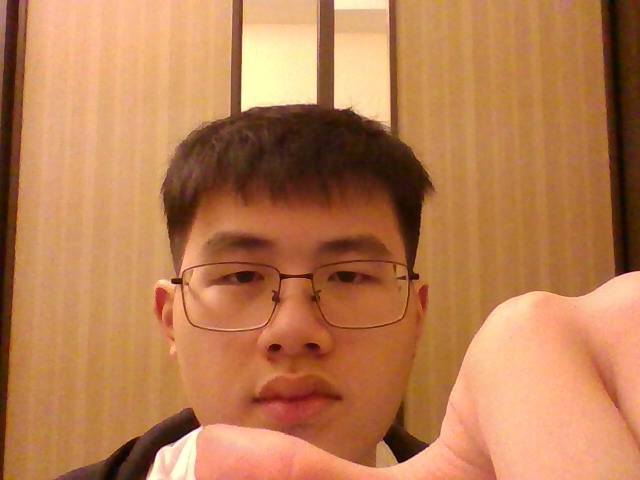

In [ ]:
import cv2
import time
from PIL import Image

vid = cv2.VideoCapture(0)
ret, frame = vid.read()
frame = cv2.flip(frame, 1)
time.sleep(2)  # Allow camera to warm up
vid.release()
cv2.destroyAllWindows()
frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
cap = Image.fromarray(frame)
display(cap)
cv2.imwrite("test.png", cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))

## **Task 2**
Convert the captured image into a LEGO-style image by using the 1x1 LEGO brick and only three colors in the bricks (e.g., white, gray, black). 

The number of LEGO bricks used in the generated image should be no more than 100x100. 

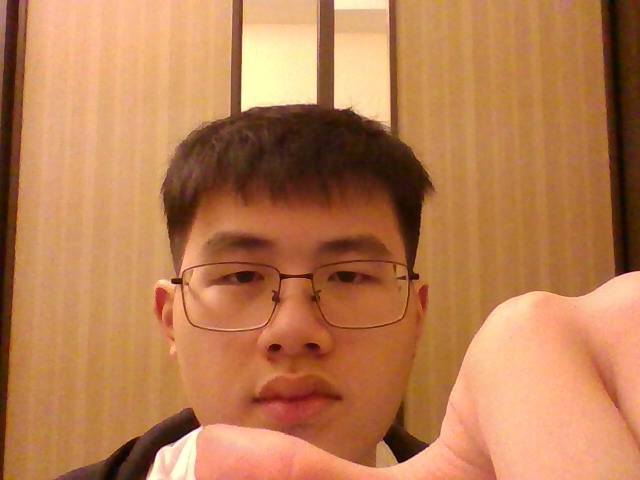

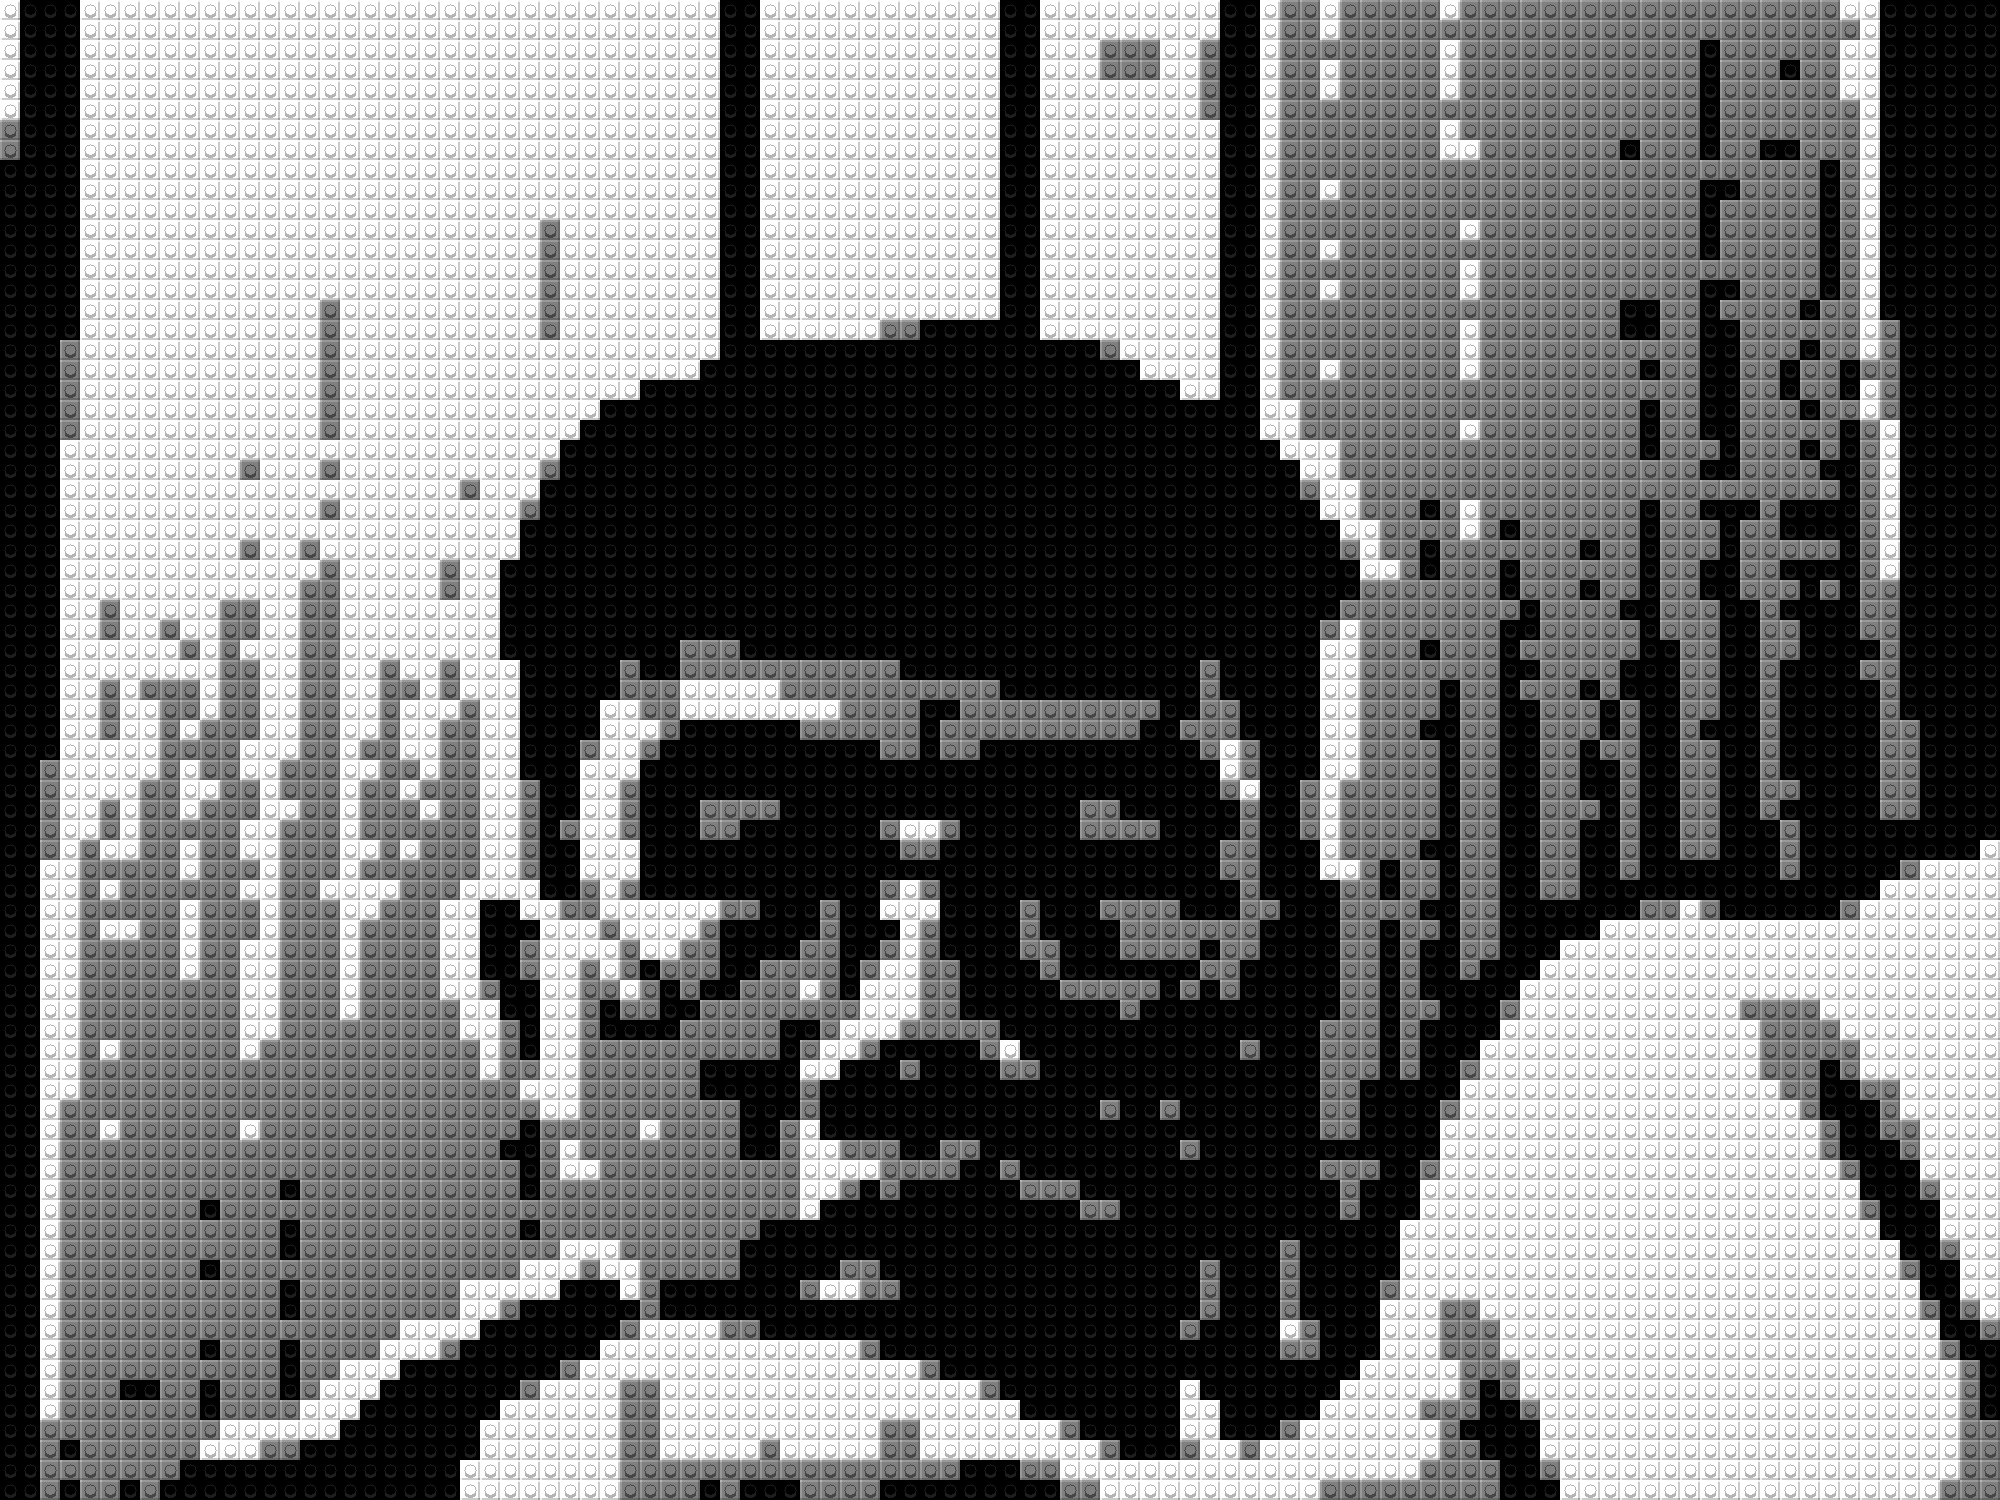

In [23]:
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

# Notic that this code was reconstructed by using object oriented programming principles.
class LegoBrick:
    # Color definitions
    BRICK_COLORS = {
        "BLACK": np.array([0, 0, 0], dtype=np.uint8),
        "GRAY": np.array([128, 128, 128], dtype=np.uint8),
        "WHITE": np.array([255, 255, 255], dtype=np.uint8)
    }
    
    # The colors for the edges and shadows of the bricks
    EDGE_COLORS = {
        (0, 0, 0): (30, 30, 30),      # black brick -> very dark edge
        (128, 128, 128): (70, 70, 70), # gray brick -> dark gray edge  
        (255, 255, 255): (180, 180, 180) # white brick -> light gray edge
    }
    
    def __init__(self, size=20):
        self.size = size
        self.center = (size // 2, size // 2)
        self.radius = size // 3
    
    def render(self, color):
        # render a single LEGO brick of given color
        brick = np.zeros((self.size, self.size, 3), dtype=np.uint8)
        
        # base color
        brick[:, :] = color
        
        # shadow (bottom-right)
        self._add_shadow(brick)
        
        # highlight (top-left)
        self._add_highlight(brick)
        
        # stud
        cv2.circle(brick, self.center, self.radius, color.tolist(), -1)
        
        # edge and stud details
        edge_color = self.EDGE_COLORS.get(tuple(color), (100, 100, 100))
        self._add_stud_detail(brick, edge_color)
        
        return brick
    
    def _add_shadow(self, brick):
        # shadow at bottom-right
        shadow = 0.8
        brick[-2:, :] = (brick[-2:, :] * shadow).astype(np.uint8)
        brick[:, -2:] = (brick[:, -2:] * shadow).astype(np.uint8)
    
    def _add_highlight(self, brick):
        # highlight at top-left
        highlight = 1.2
        brick[:2, :] = np.clip(brick[:2, :] * highlight, 0, 255).astype(np.uint8)
        brick[:, :2] = np.clip(brick[:, :2] * highlight, 0, 255).astype(np.uint8)
    
    def _add_stud_detail(self, brick, edge_color):
        # stud
        cv2.circle(brick, self.center, self.radius, edge_color, 1)
        # shadow
        cv2.ellipse(brick, self.center, (self.radius, self.radius), 
                   0, 45, 135, edge_color, 2)


class Img2LegoGray1x1:
    def __init__(self, max_bricks=100, brick_size=20, black_ratio=0.40, white_ratio=0.60):
        self.max_bricks = max_bricks
        self.brick_size = brick_size
        self.brick = LegoBrick(brick_size)
        self.black_ratio = black_ratio
        self.white_ratio = white_ratio
    
    def convert(self, img):
        img = self._resize(img)
        img = self._preprocess(img)
        lego_img = self._quantize(img)
        output = self._render(lego_img)
        
        return output
    
    def _resize(self, img):
        h, w = img.shape[:2]
        scale = min(self.max_bricks / w, self.max_bricks / h, 1.0)
        new_w, new_h = int(w * scale), int(h * scale)
        new_w = min(new_w, self.max_bricks)
        new_h = min(new_h, self.max_bricks)
        return cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    
    def _preprocess(self, img):
        # denoise with Gaussian blur
        img = cv2.GaussianBlur(img, (3, 3), 0)

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        # Edge enhancement
        kernel = np.array([[-1,-1,-1], [-1,9,-1], [-1,-1,-1]])
        return np.clip(cv2.filter2D(gray, -1, kernel), 0, 255).astype(np.uint8)
    
    def _quantize(self, gray):
        # calculate histogram to set thresholds
        hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
        hist = hist.flatten() / hist.sum()
        cumsum = np.cumsum(hist)
        
        t1 = np.where(cumsum >= self.black_ratio)[0][0]
        t2 = np.where(cumsum >= self.white_ratio)[0][0]
        
        h, w = gray.shape
        lego = np.zeros((h, w, 3), dtype=np.uint8)
        
        lego[gray < t1] = self.brick.BRICK_COLORS["BLACK"]
        lego[(gray >= t1) & (gray < t2)] = self.brick.BRICK_COLORS["GRAY"]
        lego[gray >= t2] = self.brick.BRICK_COLORS["WHITE"]
        
        return lego
    
    def _render(self, lego_img):
        h, w = lego_img.shape[:2]
        out_h, out_w = h * self.brick_size, w * self.brick_size
        output = np.zeros((out_h, out_w, 3), dtype=np.uint8)
        
        for i in range(h):
            for j in range(w):
                brick_img = self.brick.render(lego_img[i, j])
                y, x = i * self.brick_size, j * self.brick_size
                output[y:y+self.brick_size, x:x+self.brick_size] = brick_img
        
        return output

imgs = cv2.imread("test.png")
converter = Img2LegoGray1x1(max_bricks=100, brick_size=20, black_ratio=0.35, white_ratio=0.65)
display(Image.fromarray(cv2.cvtColor(imgs, cv2.COLOR_BGR2RGB)))
result = converter.convert(imgs)
display(Image.fromarray(result))

## **Task 3**
Based on Task 2, convert the captured image into a LEGO-style image by using multiple LEGO brick sizes (e.g., 1x1, 1x2, 2x4, etc.) and more than three colors in the bricks. Your program should output: 
1) A rendered LEGO-style image showing how bricks are combined. 
2) A brick summary: total number of bricks and the count for each brick type. 

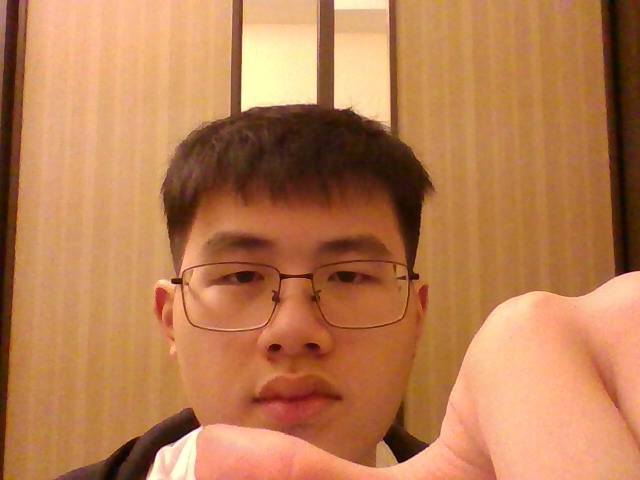

Grid size: 160x120 (19200 cells)

LEGO Brick Summary
Total bricks: 7243
Total studs (1x1 equivalent): 19200

By Size:
  4x2: 111
  2x4: 304
  4x1: 120
  2x2: 376
  1x4: 1815
  2x1: 835
  1x2: 1284
  1x1: 2398

By Color:
  nougat: 2118
  tan: 1370
  light_nougat: 1100
  brown: 1071
  dark_gray: 496
  pink: 446
  black: 263
  gray: 183
  dark_red: 88
  white: 77
  light_gray: 29
  olive: 1
  orange: 1


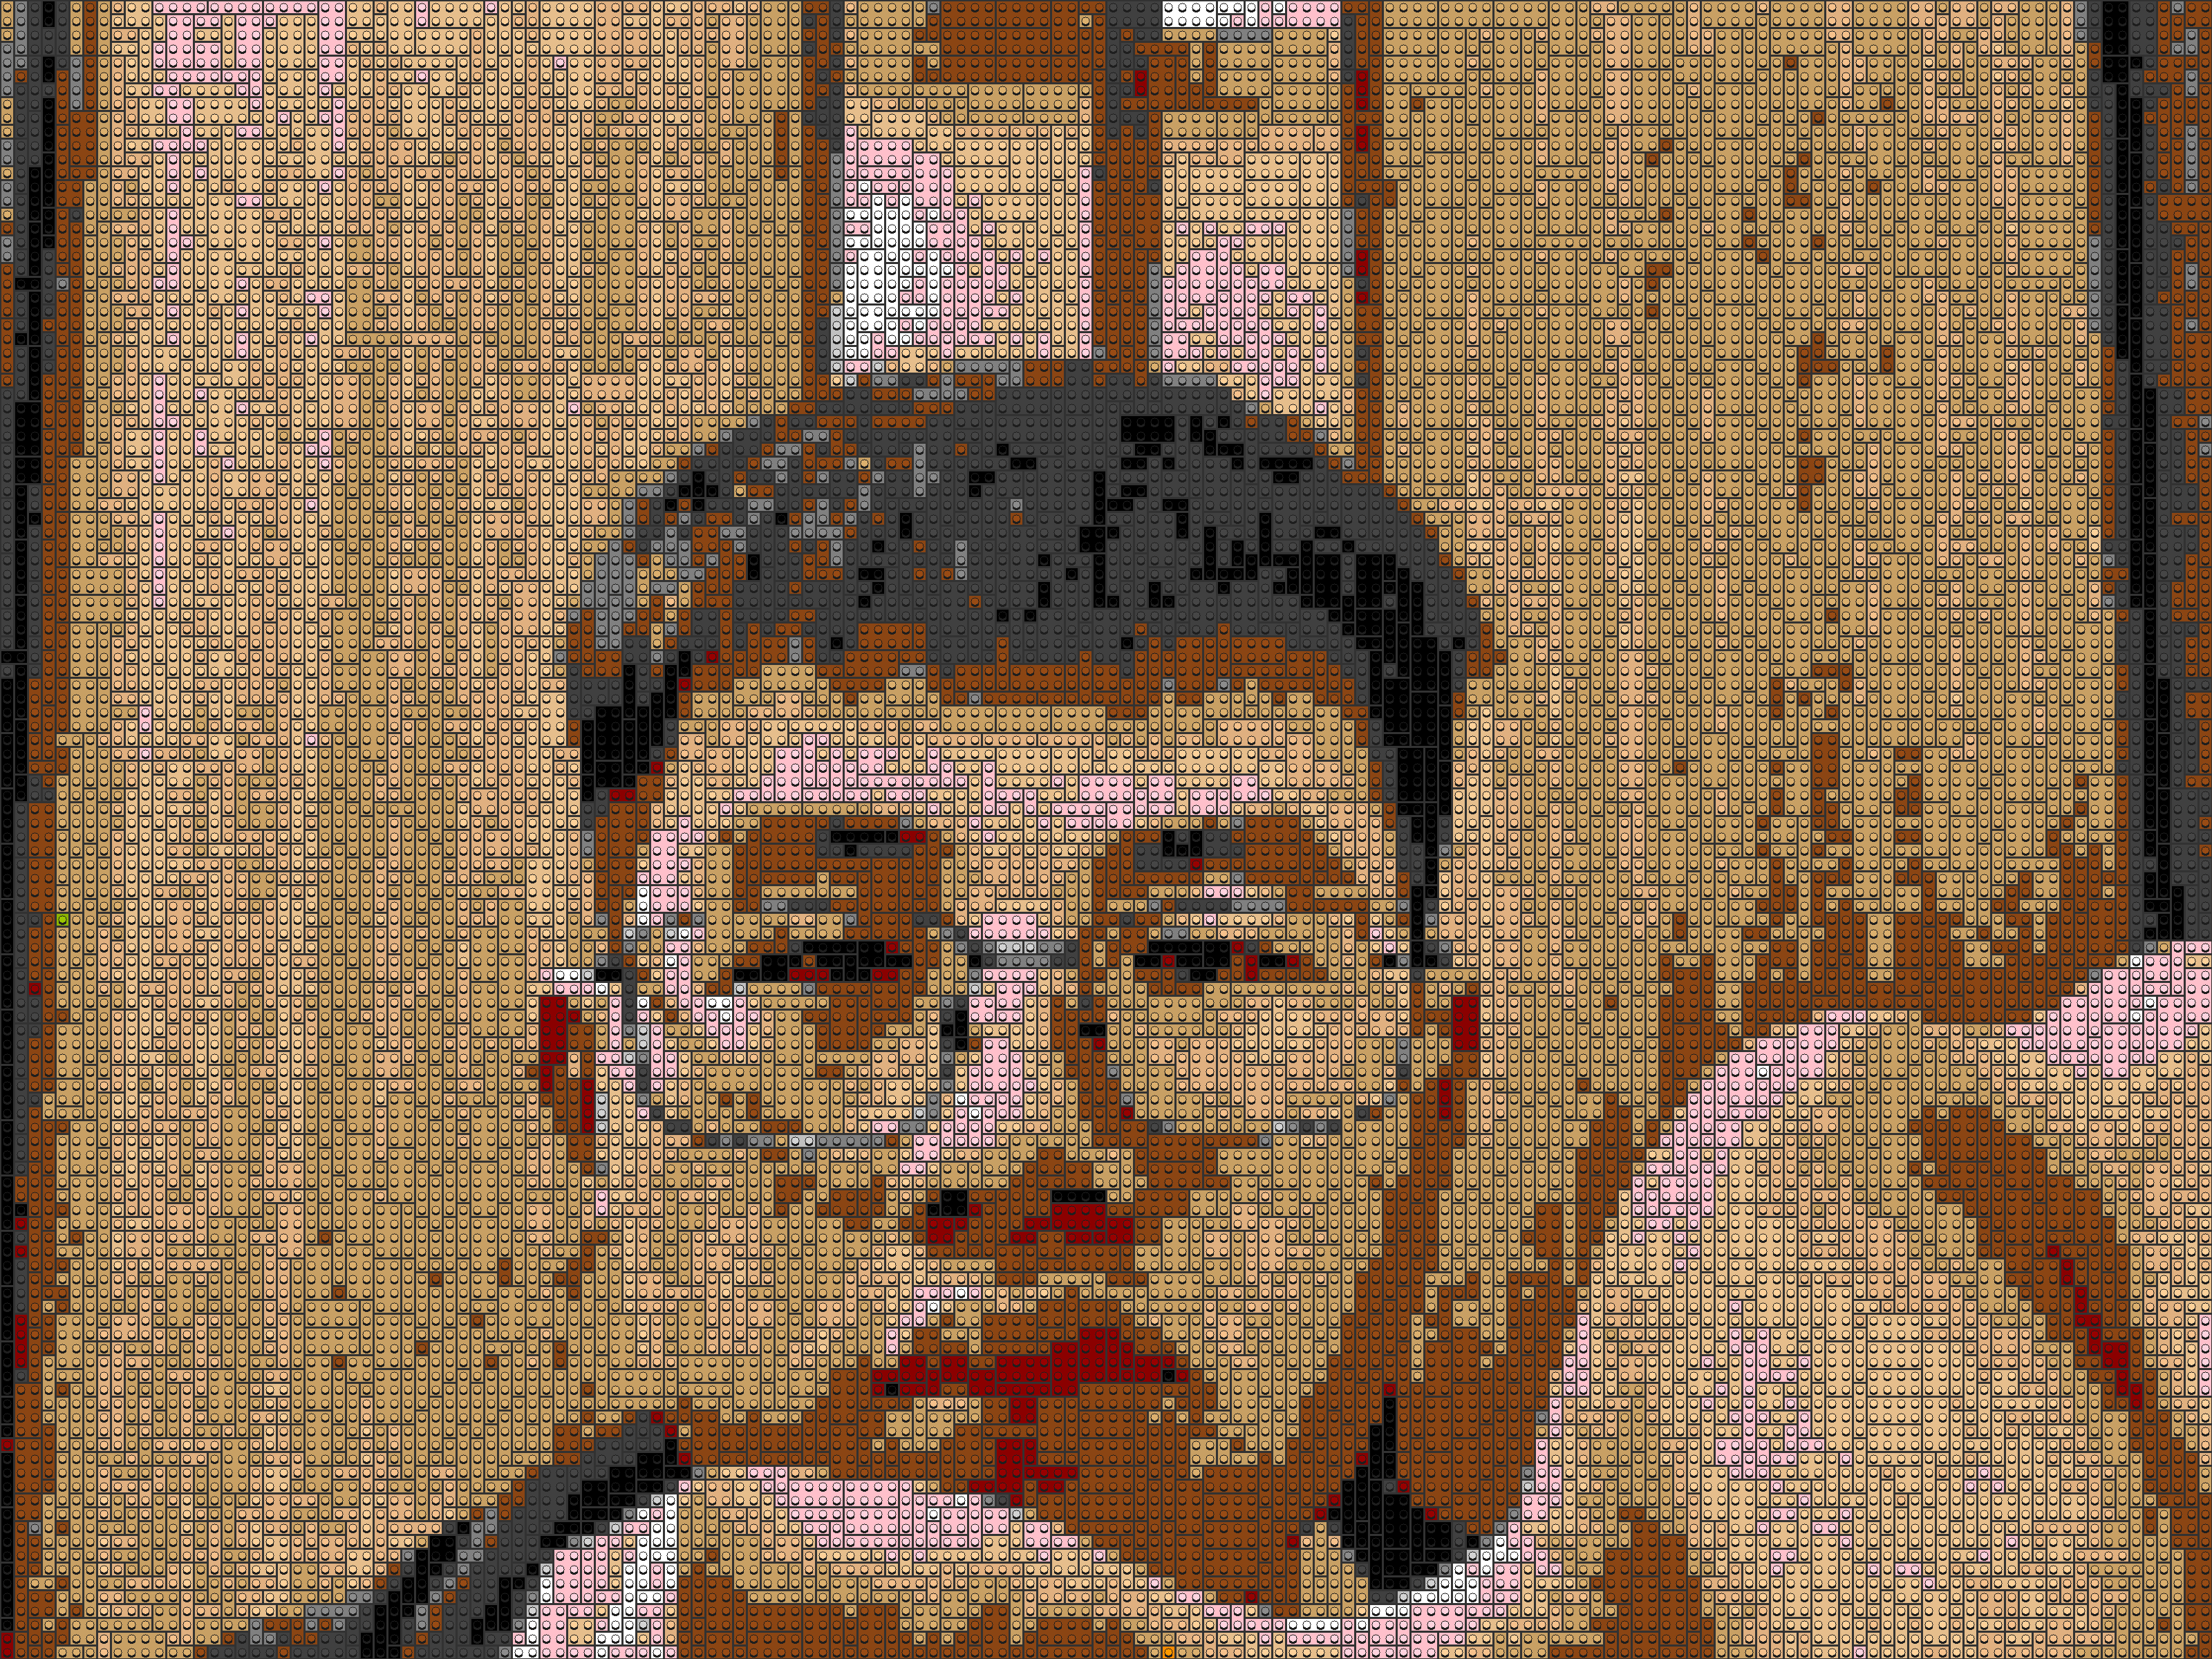

In [1]:
import numpy as np
import cv2
from PIL import Image

class Brick:
    def __init__(self, x, y, width, height, color, color_name):
        self.x = x 
        self.y = y
        self.width = width
        self.height = height
        self.color = color  # (B, G, R)
        if isinstance(color, np.ndarray):
            self.color = tuple(int(c) for c in color)
        else:
            self.color = tuple(color)
        self.color_name = color_name
    
    def size_str(self):
        return f"{self.width}x{self.height}"
    
    def area(self):
        return self.width * self.height
    

class LegoColorPalette:
    
    # In RGB format
    COLORS = {
        'white': (255, 255, 255),
        'light_gray': (192, 192, 192),
        'gray': (128, 128, 128),
        'dark_gray': (64, 64, 64),
        'black': (0, 0, 0),
        'red': (205, 0, 0),
        'light_nougat': (230, 190, 140),
        'nougat': (200, 160, 100),
        'dark_red': (139, 0, 0), 
        'orange': (255, 140, 0), 
        'yellow': (255, 255, 0),
        'warm_yellow': (255, 230, 20),
        'olive': (140, 180, 0),
        'lime': (0, 255, 0),
        'green': (0, 128, 0),
        'dark_green': (0, 100, 0),
        'cyan': (0, 255, 255), 
        'blue': (0, 0, 255), 
        'dark_blue': (0, 0, 139),
        'purple': (255, 0, 255),
        'pink': (255, 192, 203),
        'brown': (139, 69, 19),
        'tan': (224, 176, 128),
    }
    
    # Available brick sizes (width, height) in studs
    BRICK_SIZES = [(4, 2), (2, 4), (2, 2), (4, 1), (1, 4), (2, 1), (1, 2), (1, 1)]
    
    @classmethod
    def find_closest(cls, bgr_color):
        min_dist = float('inf')
        closest_name = 'black'
        closest_color = (0, 0, 0)
        
        for name, color in cls.COLORS.items():
            dist = (bgr_color[0] - color[0]) ** 2 + \
                   (bgr_color[1] - color[1]) ** 2 + \
                   (bgr_color[2] - color[2]) ** 2
            if dist < min_dist:
                min_dist = dist
                closest_name = name
                closest_color = color
        
        return closest_name, closest_color
    

class GridQuantizer:
    def __init__(self, grid_size=4):
        self.grid_size = grid_size
    
    def white_balance(self, img):
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
        l = clahe.apply(l)
        balanced = cv2.merge([l, a, b])
        return cv2.cvtColor(balanced, cv2.COLOR_LAB2BGR)

    def quantize(self, img):
        # Preprocessing
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.GaussianBlur(img, (3, 3), 0)
        img = self.white_balance(img)
        img = cv2.medianBlur(img, 3)
        kernel = np.array([[-1,-1,-1], [-1,9,-1], [-1,-1,-1]])
        img = cv2.filter2D(img, -1, kernel)
        

        # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        h, w = img.shape[:2]
        
        new_h = (h // self.grid_size) * self.grid_size
        new_w = (w // self.grid_size) * self.grid_size
        img = cv2.resize(img, (new_w, new_h))
        
        small_h = new_h // self.grid_size
        small_w = new_w // self.grid_size
        small = cv2.resize(img, (small_w, small_h), interpolation=cv2.INTER_AREA)
        
        grid = np.zeros((small_h, small_w, 3), dtype=np.uint8)
        color_names = [[None for _ in range(small_w)] for _ in range(small_h)]
        
        for i in range(small_h):
            for j in range(small_w):
                name, color = LegoColorPalette.find_closest(tuple(small[i, j]))
                grid[i, j] = color
                color_names[i][j] = name
        
        return grid, color_names, small
    

class BrickMerger:
    def __init__(self):
        self.visited = None
        self.grid = None
        self.color_names = None
        self.bricks = []
    
    def merge(self, grid, color_names):
        self.grid = grid
        self.color_names = color_names
        h, w = grid.shape[:2]
        self.visited = [[False for _ in range(w)] for _ in range(h)]
        self.bricks = []
        
        for i in range(h):
            for j in range(w):
                if self.visited[i][j]:
                    continue
                
                color = tuple(grid[i, j])
                color_name = color_names[i][j]
                
                placed = False
                for bw, bh in LegoColorPalette.BRICK_SIZES:
                    if self._can_place(i, j, bw, bh, color):
                        self._place_brick(i, j, bw, bh, color, color_name)
                        placed = True
                        break
                
                if not placed:
                    self._place_brick(i, j, 1, 1, color, color_name)
        
        return self.bricks
    
    def _can_place(self, y, x, w, h, color):
        gh, gw = self.grid.shape[:2]
        
        if x + w > gw or y + h > gh:
            return False
        
        for i in range(y, y + h):
            for j in range(x, x + w):
                if self.visited[i][j]:
                    return False
                if tuple(self.grid[i, j]) != color:
                    return False
        return True
    
    def _place_brick(self, y, x, w, h, color, color_name):
        self.bricks.append(Brick(x, y, w, h, color, color_name))
        
        for i in range(y, y + h):
            for j in range(x, x + w):
                self.visited[i][j] = True


class LegoRenderer:
    def __init__(self, brick_pixel_size=20):
        self.brick_size = brick_pixel_size
    
    def render(self, bricks, grid_h, grid_w):
        out_h = grid_h * self.brick_size
        out_w = grid_w * self.brick_size
        output = np.zeros((out_h, out_w, 3), dtype=np.uint8)
        
        for brick in bricks:
            self._render_brick(output, brick)
        
        return output
    
    def _render_brick(self, canvas, brick):
        x = brick.x * self.brick_size
        y = brick.y * self.brick_size
        w = brick.width * self.brick_size
        h = brick.height * self.brick_size

        color = tuple(int(c) for c in brick.color)
        
        cv2.rectangle(canvas, (x, y), (x + w, y + h), color, -1)
        
        border_color = (50, 50, 50)
        cv2.rectangle(canvas, (x, y), (x + w, y + h), border_color, 2)

        
        self._render_studs(canvas, x, y, w, h, brick.color)
    
    def _render_studs(self, canvas, x, y, w, h, color):
        radius = self.brick_size // 3
        
        if not isinstance(color, tuple):
            color = tuple(int(c) for c in color)
        
        cols = max(1, w // self.brick_size)
        rows = max(1, h // self.brick_size)
        
        for i in range(rows):
            for j in range(cols):
                cx = x + (j * self.brick_size) + self.brick_size // 2
                cy = y + (i * self.brick_size) + self.brick_size // 2
                
                stud_color = (
                    min(255, int(color[0] * 1.1)),
                    min(255, int(color[1] * 1.1)),
                    min(255, int(color[2] * 1.1))
                )
                cv2.circle(canvas, (cx, cy), radius, stud_color, -1)
                cv2.circle(canvas, (cx, cy), radius, (30, 30, 30), 1)
                cv2.ellipse(canvas, (cx, cy), (radius, radius), 0, 45, 135, (30, 30, 30), 2)


class LegoConverter:
    def __init__(self, grid_size=4, brick_pixel_size=20):
        self.quantizer = GridQuantizer(grid_size)
        self.merger = BrickMerger()
        self.renderer = LegoRenderer(brick_pixel_size)
        self.grid_size = grid_size
    
    def convert(self, img):
        grid, color_names, small = self.quantizer.quantize(img)
        grid_h, grid_w = grid.shape[:2]
        
        print(f"Grid size: {grid_w}x{grid_h} ({grid_w * grid_h} cells)")
        
        bricks = self.merger.merge(grid, color_names)
        
        rendered = self.renderer.render(bricks, grid_h, grid_w)
        
        stats = self._calculate_stats(bricks)
        
        return rendered, bricks, stats
    
    def _calculate_stats(self, bricks):
        stats = {
            'total_bricks': len(bricks),
            'total_stud_count': sum(b.area() for b in bricks),
            'by_size': {},
            'by_color': {},
        }
        
        for brick in bricks:
            size_str = brick.size_str()
            if size_str not in stats['by_size']:
                stats['by_size'][size_str] = 0
            stats['by_size'][size_str] += 1
            
            if brick.color_name not in stats['by_color']:
                stats['by_color'][brick.color_name] = 0
            stats['by_color'][brick.color_name] += 1
        
        return stats
    
    def print_summary(self, stats):
        print("\n" + "="*50)
        print("LEGO Brick Summary")
        print("="*50)
        print(f"Total bricks: {stats['total_bricks']}")
        print(f"Total studs (1x1 equivalent): {stats['total_stud_count']}")
        
        print("\nBy Size:")
        size_items = []
        for size, count in stats['by_size'].items():
            w, h = map(int, size.split('x'))
            size_items.append((w*h, size, count))
        size_items.sort(reverse=True)
        
        for _, size, count in size_items:
            print(f"  {size}: {count}")
        
        print("\nBy Color:")
        color_items = list(stats['by_color'].items())
        color_items.sort(key=lambda x: -x[1])
        
        for color, count in color_items:
            print(f"  {color}: {count}")


img = cv2.imread("test.png")
display(Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)))

converter = LegoConverter(grid_size=4, brick_pixel_size=20)
rendered, bricks, stats = converter.convert(img)
    
converter.print_summary(stats)
display(Image.fromarray(rendered))

## **Task 4**
Implementing and testing the program in a real-world scenario. 

Calling the camera to capture images and displaying them in LEGO style successfully.

In [9]:
# Code in a independent file "immLEGOfilter.py" because jupyter notebook cells cannot directly run a opencv window.